In [6]:
import numpy as np
import matplotlib.pyplot as plt
import random

#np.random.seed(19680801)
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

In [7]:
# Utilities for the movie
def update(frame):
    # Clear the previous plot
    ax.clear()
    
    # Plot the current matrix from your sequence
    plt.imshow(System_frames[frame])
    
    # Optionally, add titles or labels
    plt.title(f'Frame {frame}')

In [16]:
# Simulation parameters
runsNumber = 100
totalMCS = 600 #Total number of Monte Carlo steps per single run
Lx = 20 # Number of rows, width
Ly = 40 # Number of columns, length
N = Lx * Ly // 2 # Number of particles
size = Lx * Ly


# Memory allocation
System = np.zeros((Lx, Ly), dtype=int)  # Lx vectors with Ly (zero) components 
SystemSnapshot = np.zeros((Lx, Ly), dtype=int)

Corr = np.zeros(totalMCS)  # Correlation function for the whole system, vector of zeros of length totalMCS
DensityParticles = np.zeros(totalMCS) 
CurrentAlong = np.zeros(totalMCS) 
CurrentTransverse = np.zeros(totalMCS)
                   
DensityParticlesTot = np.zeros(totalMCS) 
CorrTot = np.zeros(totalMCS) 
CurrentAlongTot = np.zeros(totalMCS)  # totalMCS vectors with Ly (zero) components 
CurrentTransverseTot = np.zeros(totalMCS)  # totalMCS vectors with Ly (zero) components

System_frames = np.zeros((totalMCS+1, Lx, Ly), dtype=int)
Densitygrid = np.zeros((Lx, Ly))
DensitygridTot = np.zeros((Lx, Ly))

# Beginning of the simulation
for iwalk in range(runsNumber):
    
    # Clearing arrays from the last run
    System = np.zeros((Lx, Ly), dtype=int) 
    SystemSnapshot = np.zeros((Lx, Ly), dtype=int)
    Corr = np.zeros(totalMCS)
    DensityParticles = np.zeros(totalMCS) 
    
    CurrentAlong = np.zeros(totalMCS) 
    CurrentTransverse = np.zeros(totalMCS)
        
    # Filling the lattice with particles alternatively (chess fashion)    
    System[::2, ::2] = 1  # Set even rows and even columns to 1
    System[1::2, 1::2] = 1  # Set odd rows and odd columns to 1

    # Mapping System at t=0
    SystemSnapshot = System.copy()
    System_frames[0] = SystemSnapshot

    # Beginning of a single run
    for istep in range(totalMCS):
        CurrentAlong_temp = np.zeros((Ly)) 
        CurrentTransverse_temp = np.zeros((Lx))

        for moveAttempt in range(N):
            while True: 
                dice = random.randint(0, Lx * Ly - 1)  # Picks the random lattice site in the array
                X = dice // Ly
                Y = dice - X * Ly

                if System[X][Y] == 1:
                    # Simple implementation of Periodic boundary conditions
                    xPrev = Lx - 1 if X == 0 else X - 1
                    xNext = 0 if X == Lx - 1 else X + 1
                    yPrev = Ly - 1 if Y == 0 else Y - 1
                    yNext = 0 if Y == Ly - 1 else Y + 1    

                    # Simulating exchange dynamics  
                    # Possibility 1: p=1/2 of jumping foward, p=1/4 of jumping up or down, in total p=1/2                  
                    dice_jump = random.randint(0, 1) 
                    if dice_jump == 0:
                        JumpAlong = 0
                        JumpTransverse = 2
                    else:
                        JumpAlong = 1
                        JumpTransverse = random.randint(0, 1)
                                        
                    # Possibility 2: p=1/2 of jumping foward, jumping up or down, in total p=1                
                    #JumpAlong = random.randint(0, 2)

                    if JumpAlong == 0 and System[X][yNext] == 0:  # hop forward
                        temp = System[X][Y]
                        System[X][Y] = System[X][yNext]
                        System[X][yNext] = temp
                        CurrentAlong_temp[Y] += 1

 #                   if JumpAlong == 1 and System[X][yPrev] == 0:  # hop backward                    
 #                       temp = System[X][Y]
 #                       System[X][Y] = System[X][yPrev]
 #                       System[X][yPrev] = temp
 #                       CurrentAlong_temp[Y] -= 1

                    if JumpTransverse == 0 and System[xPrev][Y] == 0: # hop up
                        temp = System[X][Y]
                        System[X][Y] = System[xPrev][Y]
                        System[xPrev][Y] = temp
                        CurrentTransverse_temp[X] += 1


                    if JumpTransverse == 1 and System[xNext][Y] == 0:  # hop down
                        temp = System[X][Y]
                        System[X][Y] = System[xNext][Y]
                        System[xNext][Y] = temp
                        CurrentTransverse_temp[X] -= 1

                    break  # Exit the loop
                    
                    
        # Computes the total number of particles
        DensityParticles[istep] = np.sum(System) / size
        
        # Computes correlation function
        Sum = 0
        for i in range(Lx):
            for j in range(Ly):
                Sum += System[i][j] * SystemSnapshot[i][j]
        #print(Sum)
        Corr[istep] = (Sum / size) - (DensityParticles[istep])**2 # 0.25 is the density of particles^2
        
        # Computes currents
        CurrentAlong[istep] = CurrentAlong_temp.sum(axis=0)/N # Sum of the current in each lattice in Ly
        CurrentTransverse[istep] = CurrentTransverse_temp.sum(axis=0)/ N # Sum of the current in each lattice in Lx
        
        # To compute occupation probability
        Densitygrid += System
        
        # Frames for the movie
        System_frames[istep+1] = System


    # Computing parameters after a single run
    Densitygrid /= totalMCS

    for dt in range(totalMCS):
        CorrTot[dt] += Corr[dt]
        DensityParticlesTot[dt] += DensityParticles[dt] 
        CurrentAlongTot[dt] += CurrentAlong[dt]
        CurrentTransverseTot[dt] += CurrentTransverse[dt]
    DensitygridTot += Densitygrid
    
    print('Runs done:', iwalk+1)        
    
# Simulation results output
for dt in range(totalMCS):
    CorrTot[dt] /= runsNumber
    DensityParticlesTot[dt] /= (runsNumber)
    CurrentAlongTot[dt] /= (runsNumber)
    CurrentTransverseTot[dt] /= (runsNumber)

# Occupation probability of the X axis
DensitygridTot /= runsNumber
HorizontalProb = DensitygridTot.sum(axis=0)/Lx

    
print('Finished!')
        

Runs done: 1
Runs done: 2
Runs done: 3
Runs done: 4
Runs done: 5
Runs done: 6
Runs done: 7
Runs done: 8
Runs done: 9
Runs done: 10
Runs done: 11
Runs done: 12
Runs done: 13
Runs done: 14
Runs done: 15
Runs done: 16
Runs done: 17
Runs done: 18
Runs done: 19
Runs done: 20
Runs done: 21
Runs done: 22
Runs done: 23
Runs done: 24
Runs done: 25
Runs done: 26
Runs done: 27
Runs done: 28
Runs done: 29
Runs done: 30
Runs done: 31
Runs done: 32
Runs done: 33
Runs done: 34
Runs done: 35
Runs done: 36
Runs done: 37
Runs done: 38
Runs done: 39
Runs done: 40
Runs done: 41
Runs done: 42
Runs done: 43
Runs done: 44
Runs done: 45
Runs done: 46
Runs done: 47
Runs done: 48
Runs done: 49
Runs done: 50
Runs done: 51
Runs done: 52
Runs done: 53
Runs done: 54
Runs done: 55
Runs done: 56
Runs done: 57
Runs done: 58
Runs done: 59
Runs done: 60
Runs done: 61
Runs done: 62
Runs done: 63
Runs done: 64
Runs done: 65
Runs done: 66
Runs done: 67
Runs done: 68
Runs done: 69
Runs done: 70
Runs done: 71
Runs done: 72
R

In [17]:
# Movie for the last run. Recommended when MCS is not higher than 200

# fig, ax = plt.subplots()
# ani = FuncAnimation(fig, update, frames=len(System_frames), repeat=False)

# HTML(ani.to_jshtml())

1) total number of particles stays constant at all times


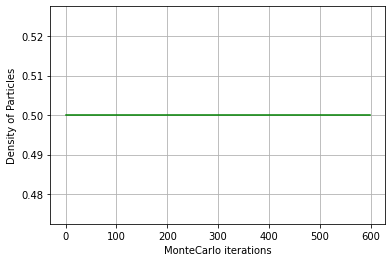

In [18]:
# Testing Area

print('1) total number of particles stays constant at all times')

x_axis=np.array(range(totalMCS))
plt.plot(x_axis, DensityParticlesTot, color='green')
plt.xlabel('MonteCarlo iterations')
plt.ylabel('Density of Particles')
plt.grid(True) 

plt.show()

2) Autocorrelation function ~ 1/t


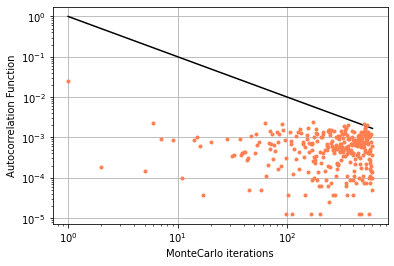

In [19]:
print('2) Autocorrelation function ~ 1/t')

x_axis=np.array(range(1,totalMCS+1))
f=1/x_axis
plt.plot(x_axis, f, color='black')
plt.plot(x_axis, CorrTot, '.', color='coral')
plt.xlabel('MonteCarlo iterations')
plt.ylabel('Autocorrelation Function')
plt.xscale('log')
plt.yscale('log')
plt.grid(True) 

plt.show()

3) parallel current ~ rewrite & Perpendicular Current=0


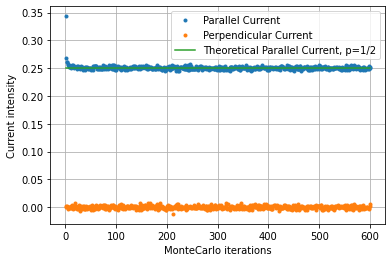

In [20]:
print('3) parallel current ~ rewrite & Perpendicular Current=0')

# Ruslan: Situation where each direction is chosen with equal probability, p=1/2 and you should get 0.125 current value for rho=1/2. 
#Another choice is to have 1/4 for jump up, 1/4 for jump down and 1/2 for jump forward probabilities, and then your p=1 and the current will be 0.25. 
#Both of these choices should only differ in the timescale, i.e., one case would transform to another by simple t'=2t rescaling. So you can try any of them

#The steady current of particle J, through a bond i, i+1 is given by the rate r multiplied by the probability that there is a particle at site i, and site i+1 is vacant
r=1
p=1/2
prob_vac=1/2
f2=np.array([r*p*prob_vac]*totalMCS)
f3=np.array([0.25]*totalMCS)

plt.plot(x_axis, CurrentAlongTot, '.', label='Parallel Current')
plt.plot(x_axis, CurrentTransverseTot, '.', label='Perpendicular Current')
#plt.plot(x_axis,f2, label='Theoretical Parallel Current, p=1')
plt.plot(x_axis,f3, label='Theoretical Parallel Current, p=1/2')

plt.xlabel('MonteCarlo iterations')
plt.ylabel('Current intensity')
plt.legend()
plt.grid(True)

plt.show()

4) Occupation probability


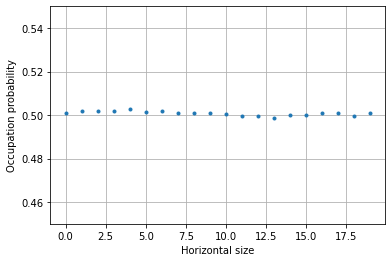

In [23]:
print('4) Occupation probability')

x_axis=np.array(range(Ly))

plt.plot(x_axis, HorizontalProb, '.')

plt.xlabel('Horizontal size')
plt.ylabel('Occupation probability')
plt.ylim([0.45,0.55])
plt.grid(True)

plt.show()